In [189]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder






##Data loading


In [190]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

train_path = DATA_DIR / "geologicalTrain.zip"

In [191]:
import zipfile
with zipfile.ZipFile("../data/geologicalTrain.zip", "r") as zip_ref:
    zip_ref.extractall("../data/")

###Load dataset

In [192]:
train_csv = glob.glob(os.path.join(train_path, "*.csv"))

print("Train CSV:", train_csv)

Train CSV: []


Directing the path of dataset

In [193]:
train_path = r"c:\Users\hp\groundwater-system-1\data\geologicalTrain"

train_csv = glob.glob(os.path.join(train_path, "*.csv"))
print("Idadi ya faili:", len(train_csv))
print("Mfano:", train_csv[:5])

Idadi ya faili: 952
Mfano: ['c:\\Users\\hp\\groundwater-system-1\\data\\geologicalTrain\\000d7d20__horizontal_well.csv', 'c:\\Users\\hp\\groundwater-system-1\\data\\geologicalTrain\\000d7d20__typewell.csv', 'c:\\Users\\hp\\groundwater-system-1\\data\\geologicalTrain\\00bbac68__horizontal_well.csv', 'c:\\Users\\hp\\groundwater-system-1\\data\\geologicalTrain\\00bbac68__typewell.csv', 'c:\\Users\\hp\\groundwater-system-1\\data\\geologicalTrain\\00e12e8b__horizontal_well.csv']


In [194]:
df_train = pd.read_csv(train_csv[0])

df_train.head()


,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
0,11467.0,2983525.16,1069022.09,-9258.57,-9395.81,-9569.86,-9597.64,-9670.99,-9705.96,-9846.35,11236.02,115.692586,11236.02
1,11468.0,2983525.18,1069022.30,-9259.55,-9395.75,-9569.80,-9597.58,-9670.93,-9705.90,-9846.29,11237.05,115.584293,11237.05
2,11469.0,2983525.20,1069022.52,-9260.52,-9395.69,-9569.74,-9597.52,-9670.87,-9705.84,-9846.23,11238.09,135.446960,11238.09
3,11470.0,2983525.22,1069022.73,-9261.50,-9395.64,-9569.69,-9597.47,-9670.82,-9705.79,-9846.18,11239.12,140.401346,11239.12
4,11471.0,2983525.25,1069022.95,-9262.47,-9395.58,-9569.63,-9597.41,-9670.76,-9705.73,-9846.12,11240.15,111.270638,11240.15


###check dataset shape

In [195]:
print(df_train.shape)

(5278, 13)


In [196]:
df_train.head()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
0,11467.0,2983525.16,1069022.09,-9258.57,-9395.81,-9569.86,-9597.64,-9670.99,-9705.96,-9846.35,11236.02,115.692586,11236.02
1,11468.0,2983525.18,1069022.30,-9259.55,-9395.75,-9569.80,-9597.58,-9670.93,-9705.90,-9846.29,11237.05,115.584293,11237.05
2,11469.0,2983525.20,1069022.52,-9260.52,-9395.69,-9569.74,-9597.52,-9670.87,-9705.84,-9846.23,11238.09,135.446960,11238.09
3,11470.0,2983525.22,1069022.73,-9261.50,-9395.64,-9569.69,-9597.47,-9670.82,-9705.79,-9846.18,11239.12,140.401346,11239.12
4,11471.0,2983525.25,1069022.95,-9262.47,-9395.58,-9569.63,-9597.41,-9670.76,-9705.73,-9846.12,11240.15,111.270638,11240.15


###Checking the colomn features

In [197]:
print(df_train.columns.tolist())

['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input']


###checking missing values

In [198]:
print("Missing values in training dataset:")
print(df_train.isnull().sum())



Missing values in training dataset:
MD              0
X               0
Y               0
Z               0
ANCC            0
ASTNU           0
ASTNL           0
EGFDU           0
EGFDL           0
BUDA            0
TVT             0
GR           2258
TVT_input    3836
dtype: int64


###Handling missing values

In [199]:
#For GR values only

from sklearn.impute import KNNImputer


df_train['GR_was_missing'] = df_train['GR'].isnull().astype(int)


common_predictors = ['MD', 'X', 'Y', 'Z', 'GR']


imputer = KNNImputer(n_neighbors=5)


df_train[common_predictors] = imputer.fit_transform(
    df_train[common_predictors]
)


print("GR missing values after imputation:",
      df_train['GR'].isnull().sum())

GR missing values after imputation: 0


In [200]:
print("Missing values in training dataset:")
print(df_train.isnull().sum())

Missing values in training dataset:
MD                   0
X                    0
Y                    0
Z                    0
ANCC                 0
ASTNU                0
ASTNL                0
EGFDU                0
EGFDL                0
BUDA                 0
TVT                  0
GR                   0
TVT_input         3836
GR_was_missing       0
dtype: int64


###checking correlation of TVT_input for missing value decision handling

In [201]:
corr = df_train.corr(numeric_only=True)['TVT_input'].sort_values(ascending=False)

print(corr)

TVT               1.000000
TVT_input         1.000000
MD                0.846581
Y                 0.785926
EGFDU             0.719790
ASTNL             0.719790
ANCC              0.719790
EGFDL             0.719790
ASTNU             0.719790
BUDA              0.719790
X                 0.707033
GR_was_missing    0.320057
GR               -0.097171
Z                -0.999188
Name: TVT_input, dtype: float64


###Drop TVT_input due to target leakage (perfect correlation with target TVT)

In [202]:

df_train = df_train.drop(columns=['TVT_input'])

###Check again missing values for making sure that the handling method perfom well

In [203]:
print("Missing values in training dataset:")
print(df_train.isnull().sum())

Missing values in training dataset:
MD                0
X                 0
Y                 0
Z                 0
ANCC              0
ASTNU             0
ASTNL             0
EGFDU             0
EGFDL             0
BUDA              0
TVT               0
GR                0
GR_was_missing    0
dtype: int64


###Checking for Duplication records

In [204]:
print("Duplicate rows in training:", df_train.duplicated().sum())

Duplicate rows in training: 0


###stastical summary

In [205]:
df_train.describe()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,GR_was_missing
count,5278.000000,5.278000e+03,5.278000e+03,5278.000000,5278.000000,5278.000000,5278.000000,5278.000000,5278.000000,5278.000000,5278.000000,5278.000000,5278.000000
mean,14105.500000,2.983514e+06,1.071418e+06,-9673.194324,-9330.621821,-9504.671821,-9532.451821,-9605.801821,-9640.771821,-9781.161821,11715.831127,95.288524,0.427814
std,1523.771691,2.997379e+01,1.503381e+03,80.961903,35.272977,35.272977,35.272977,35.272977,35.272977,35.272977,88.782092,16.847597,0.494809
min,11467.000000,2.983468e+06,1.069022e+06,-9755.610000,-9395.810000,-9569.860000,-9597.640000,-9670.990000,-9705.960000,-9846.350000,11236.020000,31.765827,0.000000
25%,12786.250000,2.983487e+06,1.070090e+06,-9721.762500,-9362.307500,-9536.357500,-9564.137500,-9637.487500,-9672.457500,-9812.847500,11735.850000,86.564135,0.000000
50%,14105.500000,2.983514e+06,1.071407e+06,-9689.230000,-9335.975000,-9510.025000,-9537.805000,-9611.155000,-9646.125000,-9786.515000,11742.130000,94.936506,0.000000
75%,15424.750000,2.983535e+06,1.072723e+06,-9650.035000,-9296.665000,-9470.715000,-9498.495000,-9571.845000,-9606.815000,-9747.205000,11747.257500,103.656316,1.000000
max,16744.000000,2.983578e+06,1.074041e+06,-9258.570000,-9271.000000,-9445.050000,-9472.830000,-9546.180000,-9581.150000,-9721.540000,11756.120000,217.352257,1.000000


###Basic infomation summary

In [206]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5278 entries, 0 to 5277
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MD              5278 non-null   float64
 1   X               5278 non-null   float64
 2   Y               5278 non-null   float64
 3   Z               5278 non-null   float64
 4   ANCC            5278 non-null   float64
 5   ASTNU           5278 non-null   float64
 6   ASTNL           5278 non-null   float64
 7   EGFDU           5278 non-null   float64
 8   EGFDL           5278 non-null   float64
 9   BUDA            5278 non-null   float64
 10  TVT             5278 non-null   float64
 11  GR              5278 non-null   float64
 12  GR_was_missing  5278 non-null   int64  
dtypes: float64(12), int64(1)
memory usage: 536.2 KB


EDA(EXPLORATORY DATA ANALYSIS)

###Check if feautures are normally distributed and detects skewness

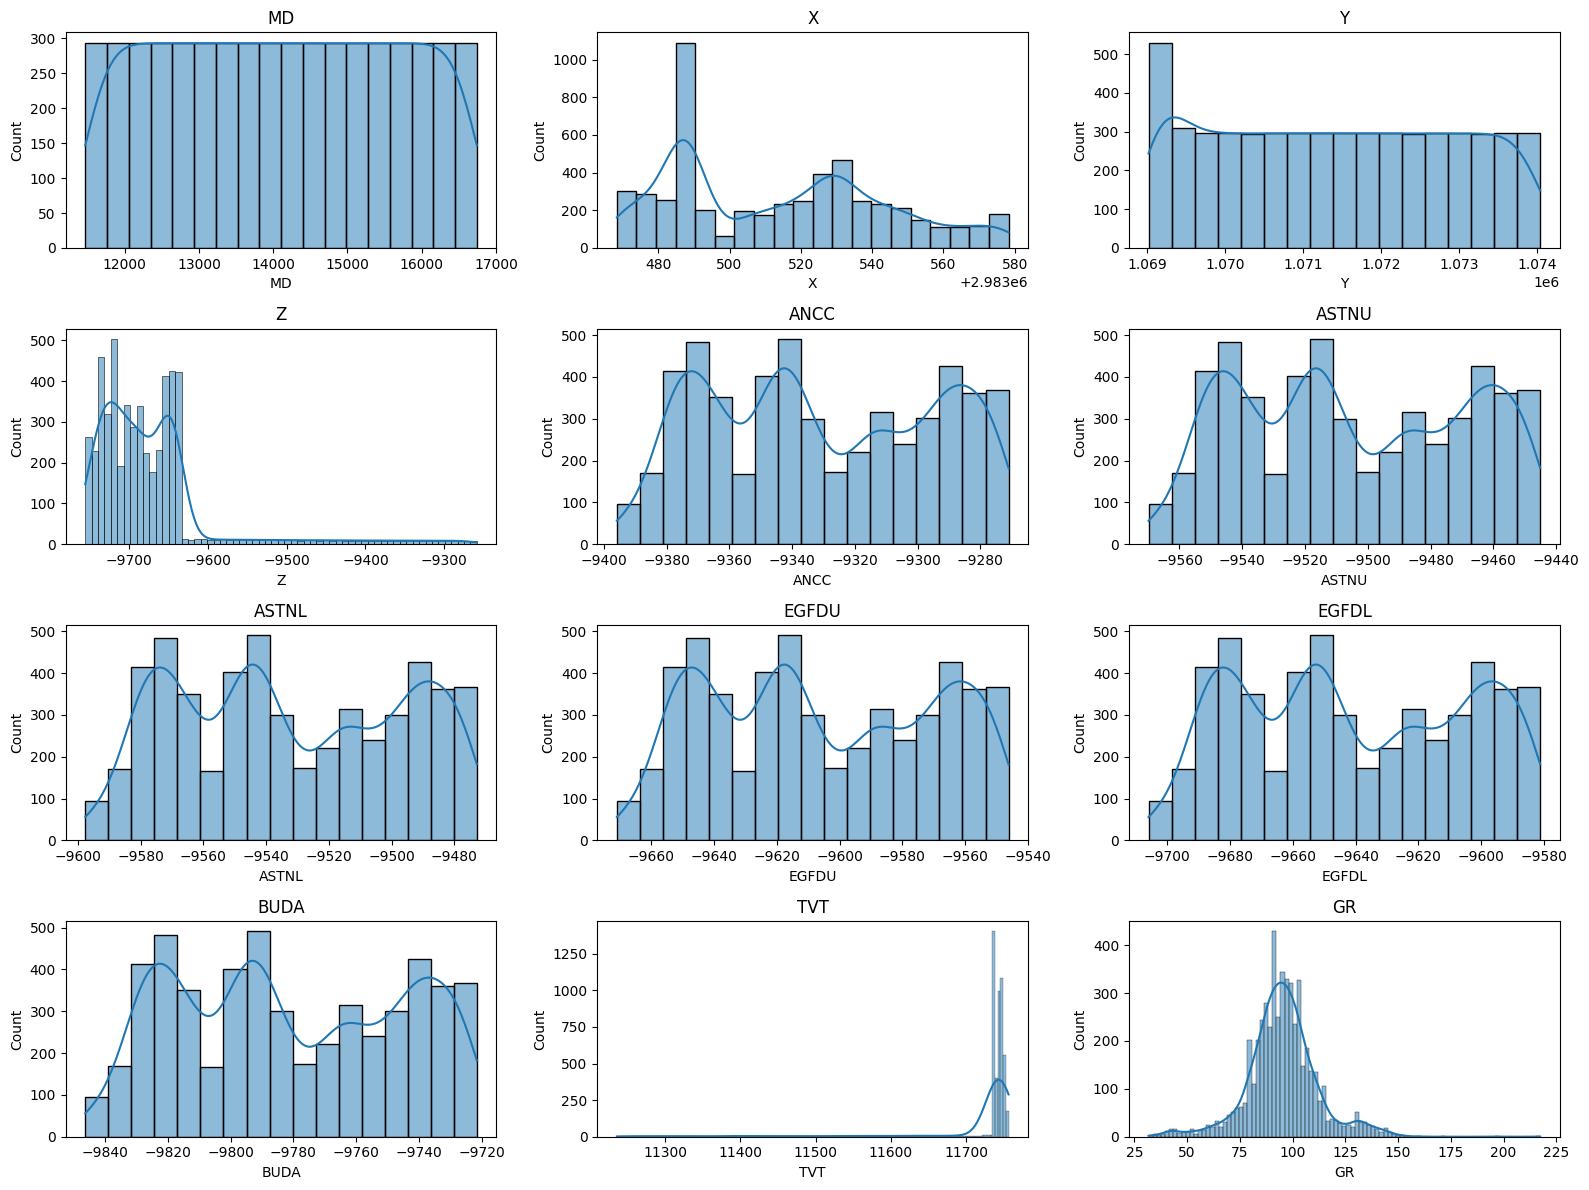

In [207]:
features = ['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR']
plt.figure(figsize=(16, 12))
for i, col in enumerate(features):
  plt.subplot(4, 3, i+1)
  sns.histplot(df_train[col], kde=True)
  plt.title(col)
plt.tight_layout()
plt.show()



###Boxplots for Outlier Detection

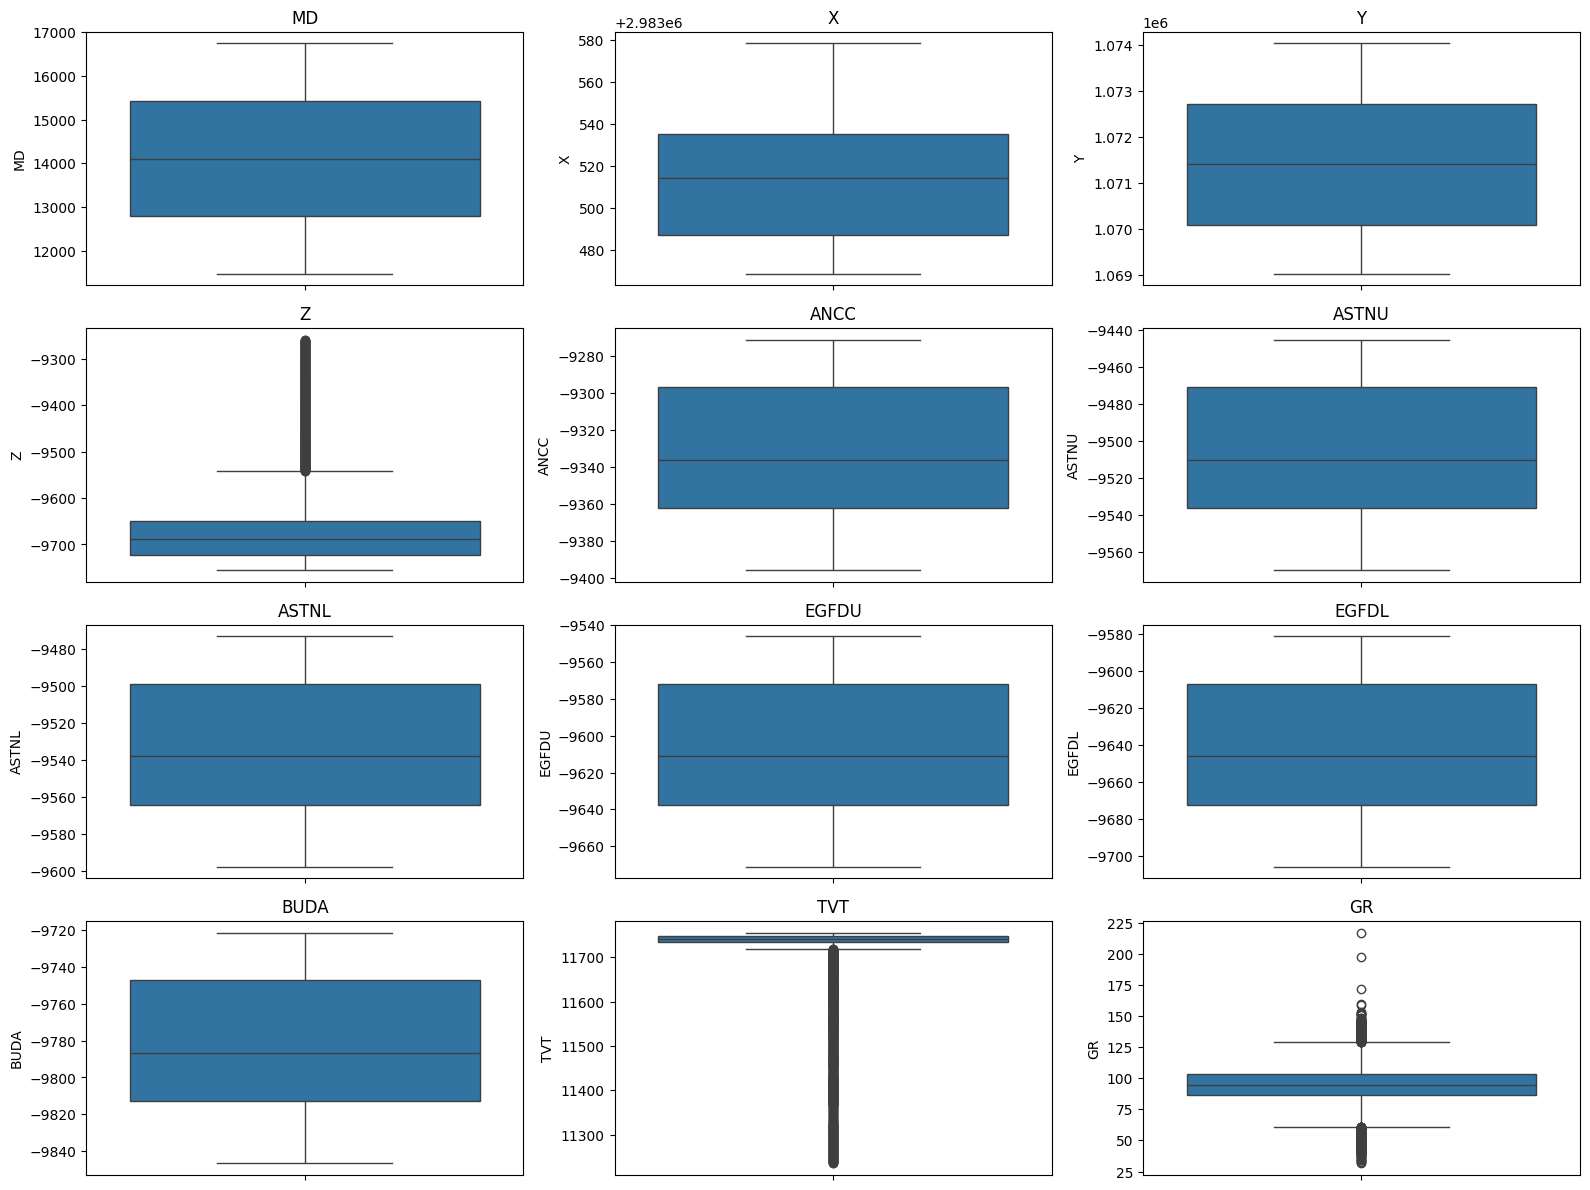

In [208]:
plt.figure(figsize=(16, 12))
for i, col in enumerate(features):
  plt.subplot(4, 3, i+1)
  sns.boxplot(df_train[col])
  plt.title(col)
plt.tight_layout()
plt.show()


In [209]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column}: {len(outliers)} outliers in {len(df)} rows is ({len(outliers)/len(df)*100:.1f}%)")
    return outliers

for col in ['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR']:
    detect_outliers_iqr(df_train, col)

MD: 0 outliers in 5278 rows is (0.0%)
X: 0 outliers in 5278 rows is (0.0%)
Y: 0 outliers in 5278 rows is (0.0%)
Z: 322 outliers in 5278 rows is (6.1%)
ANCC: 0 outliers in 5278 rows is (0.0%)
ASTNU: 0 outliers in 5278 rows is (0.0%)
ASTNL: 0 outliers in 5278 rows is (0.0%)
EGFDU: 0 outliers in 5278 rows is (0.0%)
EGFDL: 0 outliers in 5278 rows is (0.0%)
BUDA: 0 outliers in 5278 rows is (0.0%)
TVT: 618 outliers in 5278 rows is (11.7%)
GR: 391 outliers in 5278 rows is (7.4%)


###Data preprocessing

####Separate features (x) and target (y=MD)  

In [210]:


X_train = df_train.drop(columns=['MD'])
y_train = df_train['MD']

####Separate data into train(80%) and test (20%)

In [211]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [212]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4222, 12)
X_test: (1056, 12)
y_train: (4222,)
y_test: (1056,)


##Model training and evaluation

###Train RandomForest Regressor

In [213]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

depth_model = RandomForestRegressor(n_estimators=200, random_state=42)
depth_model.fit(X_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

###Evaluate Model Performance (RMSE, R²)

In [214]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

val_predictions = depth_model.predict(X_train)
rmse = np.sqrt(mean_squared_error(y_train, val_predictions))

print("RMSE:", rmse)
print("R² Score:", r2_score(y_train, val_predictions))

RMSE: 0.2236235067288909
R² Score: 0.9999999782786383


#Prediction on test dataset

In [215]:

y_pred =depth_model.predict(X_test)

results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})



results_df = results_df.reset_index(drop=True)




print(results_df.head(10))

    Actual  Predicted
0  11475.0  11474.520
1  15713.0  15712.900
2  12011.0  12011.145
3  13247.0  13246.865
4  15407.0  15407.565
5  13031.0  13030.570
6  15986.0  15986.720
7  14131.0  14131.640
8  11634.0  11634.050
9  11813.0  11813.490


###Feature importances

In [216]:

importances = pd.Series(depth_model.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False))

Y                 2.359942e-01
ASTNL             1.349292e-01
ASTNU             1.324248e-01
EGFDU             1.256736e-01
BUDA              1.252940e-01
EGFDL             1.135393e-01
ANCC              1.057856e-01
Z                 1.843362e-02
TVT               6.788120e-03
X                 1.136160e-03
GR                1.283201e-06
GR_was_missing    2.461144e-08
dtype: float64


In [217]:
import joblib
model_path = "/content/drive/MyDrive/geological_models"
os.makedirs(model_path, exist_ok=True)

print(model_path)

joblib.dump(
    depth_model,
    f"{model_path}/depth_model.pkl"
)
print("Depth model saved successfully!")

/content/drive/MyDrive/geological_models
Depth model saved successfully!


# **MODEL 2: FOR ROCK TYPES**

###Data loading and missng values checking

In [218]:
import pandas as pd

df = pd.read_csv("../data/force.csv", sep=";")

print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (1170511, 29)

Missing values:
WELL                                       0
DEPTH_MD                                   0
X_LOC                                  10775
Y_LOC                                  10775
Z_LOC                                  10775
GROUP                                   1278
FORMATION                             136994
CALI                                   87877
RSHA                                  539861
RMED                                   38993
RDEP                                   11015
RHOB                                  161269
GR                                         0
SGR                                  1101158
NPHI                                  405102
PEF                                   498819
DTC                                    80863
SP                                    306264
BS                                    487854
ROP                                   635440
DTS                                   995898
DCAL             

###checking data shape and separating target values

In [219]:
target = "FORCE_2020_LITHOFACIES_LITHOLOGY"

data = df.dropna(subset=[target]).copy()

print("Data prepared successfully")
print("Shape:", data.shape)

Data prepared successfully
Shape: (1170511, 29)


In [220]:
target = "FORCE_2020_LITHOFACIES_LITHOLOGY"

X = df.drop(columns=[target, "FORCE_2020_LITHOFACIES_CONFIDENCE"])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget classes:")
print(y.value_counts().sort_index())

X shape: (1170511, 27)
y shape: (1170511,)

Target classes:
FORCE_2020_LITHOFACIES_LITHOLOGY
30000    168937
65000    720803
65030    150455
70000     56320
70032     10513
74000      1688
80000     33329
86000      1085
88000      8213
90000      3820
93000       103
99000     15245
Name: count, dtype: int64


###Checking the features

In [221]:
print(X.columns.tolist())

['WELL', 'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC', 'GROUP', 'FORMATION', 'CALI', 'RSHA', 'RMED', 'RDEP', 'RHOB', 'GR', 'SGR', 'NPHI', 'PEF', 'DTC', 'SP', 'BS', 'ROP', 'DTS', 'DCAL', 'DRHO', 'MUDWEIGHT', 'RMIC', 'ROPA', 'RXO']


In [222]:

data_fe = data.copy()


data_fe = data_fe.sort_values(
    ["WELL", "DEPTH_MD"]
).reset_index(drop=True)

print("data_fe created successfully")
print("Shape:", data_fe.shape)

data_fe created successfully
Shape: (1170511, 29)


In [223]:
print("df shape:", df.shape)
print("data shape:", data.shape)
print("data_fe shape:", data_fe.shape)

print("\nTarget column:")
print(target)

print("\nTarget values:")
print(data[target].value_counts(dropna=False))

df shape: (1170511, 29)
data shape: (1170511, 29)
data_fe shape: (1170511, 29)

Target column:
FORCE_2020_LITHOFACIES_LITHOLOGY

Target values:
FORCE_2020_LITHOFACIES_LITHOLOGY
65000    720803
30000    168937
65030    150455
70000     56320
80000     33329
99000     15245
70032     10513
88000      8213
90000      3820
74000      1688
86000      1085
93000       103
Name: count, dtype: int64


In [224]:
log_cols = ["GR", "RHOB", "NPHI", "DTC", "CALI", "SP"]

for col in log_cols:
    data_fe[f"{col}_diff"] = (
        data_fe.groupby("WELL")[col].diff()
    )

print("Difference features created successfully")

Difference features created successfully


In [225]:
rolling_cols = ["GR", "RHOB", "NPHI", "DTC"]

for col in rolling_cols:


    data_fe[f"{col}_roll_mean"] = (
        data_fe.groupby("WELL")[col]
        .transform(
            lambda s: s.rolling(
                window=5,
                min_periods=1,
                center=True
            ).mean()
        )
    )


    data_fe[f"{col}_roll_std"] = (
        data_fe.groupby("WELL")[col]
        .transform(
            lambda s: s.rolling(
                window=5,
                min_periods=2,
                center=True
            ).std()
        )
    )

print("Rolling features created successfully")
print("New shape:", data_fe.shape)

Rolling features created successfully
New shape: (1170511, 43)


In [226]:
final_features = [
    "DEPTH_MD",
    "CALI",
    "RSHA",
    "RMED",
    "RDEP",
    "RHOB",
    "GR",
    "NPHI",
    "PEF",
    "DTC",
    "SP",
    "GR_diff",
    "RHOB_diff",
    "NPHI_diff",
    "DTC_diff",
    "CALI_diff",
    "SP_diff",
    "GR_roll_mean",
    "GR_roll_std",
    "RHOB_roll_mean",
    "RHOB_roll_std",
    "NPHI_roll_mean",
    "NPHI_roll_std",
    "DTC_roll_mean",
    "DTC_roll_std"
]

X = data_fe[final_features].copy()
y = data_fe[target].copy()
groups = data_fe["WELL"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1170511, 25)
y shape: (1170511,)


###Split data into training and testing dataset



In [227]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (894269, 25)
X_test : (276242, 25)
y_train: (894269,)
y_test : (276242,)


###Handle missing values

In [228]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=final_features,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=final_features,
    index=X_test.index
)

print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test :", X_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test : 0


###Model training and prediction

###Model Evaluation

checking class imbalance

In [229]:
import pandas as pd

class_counts = y_train.value_counts().sort_index()

print("Training class distribution:")
print(class_counts)

print("\nPercentage distribution:")
print((class_counts / len(y_train) * 100).round(2))

Training class distribution:
FORCE_2020_LITHOFACIES_LITHOLOGY
30000    130955
65000    544747
65030    121183
70000     43889
70032      7938
74000      1193
80000     22389
86000       845
88000      4314
90000      3306
93000       103
99000     13407
Name: count, dtype: int64

Percentage distribution:
FORCE_2020_LITHOFACIES_LITHOLOGY
30000    14.64
65000    60.92
65030    13.55
70000     4.91
70032     0.89
74000     0.13
80000     2.50
86000     0.09
88000     0.48
90000     0.37
93000     0.01
99000     1.50
Name: count, dtype: float64


##Using SMOTE to handle class imbalance

In [230]:
%pip install -q imbalanced-learn
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully!")

Note: you may need to restart the kernel to use updated packages.
SMOTE imported successfully!



[notice] A new release of pip is available: 25.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [231]:
from imblearn.over_sampling import SMOTE

print("imblearn import succeeded")

imblearn import succeeded


In [232]:
from imblearn.over_sampling import SMOTE

class_counts = y_train.value_counts()
requested_counts = {
    70032: 15000,
    74000: 5000,
    80000: 25000,
    86000: 5000,
    88000: 8000,
    90000: 8000,
    93000: 2000,
    99000: 15000
}

smote_strategy = {
    label: target_count
    for label, target_count in requested_counts.items()
    if label in class_counts and target_count > class_counts[label]
}

if smote_strategy:
    minimum_class_count = min(class_counts[label] for label in smote_strategy)
    if minimum_class_count < 2:
        raise ValueError("SMOTE needs at least two samples in every oversampled class")
    smote = SMOTE(
        sampling_strategy=smote_strategy,
        random_state=42,
        k_neighbors=min(5, minimum_class_count - 1)
    )
    X_train_smote, y_train_smote = smote.fit_resample(
        X_train,
        y_train
    )
else:
    X_train_smote, y_train_smote = X_train.copy(), y_train.copy()

print("Original training data:", X_train.shape)
print("After SMOTE:", X_train_smote.shape)
print("\nClass distribution after SMOTE:")
print(y_train_smote.value_counts())

Original training data: (894269, 25)
After SMOTE: (923774, 25)

Class distribution after SMOTE:
FORCE_2020_LITHOFACIES_LITHOLOGY
65000    544747
30000    130955
65030    121183
70000     43889
80000     25000
99000     15000
70032     15000
90000      8000
88000      8000
74000      5000
86000      5000
93000      2000
Name: count, dtype: int64


###Model training and evaluation

In [233]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

smote_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight=None,
    n_jobs=-1,
    random_state=42
)

smote_model.fit(X_train_smote, y_train_smote)

print("Model trained successfully!")

Model trained successfully!


In [234]:
y_pred_smote = smote_model.predict(X_test)

test_results = pd.DataFrame({
    "Actual_Rock_Type": y_test.values,
    "Predicted_Rock_Type": y_pred_smote
})
test_results["Result"] = (
    test_results["Actual_Rock_Type"] == test_results["Predicted_Rock_Type"]
)

print(test_results.head(20))

    Actual_Rock_Type  Predicted_Rock_Type  Result
0              65000                65000    True
1              65000                65000    True
2              65000                65000    True
3              65000                65000    True
4              65000                65000    True
5              65000                65000    True
6              65000                65000    True
7              65000                65000    True
8              65000                65000    True
9              65000                65000    True
10             65000                65000    True
11             65000                65000    True
12             65000                65000    True
13             65000                65000    True
14             65000                65000    True
15             65000                65000    True
16             65000                65000    True
17             65000                65000    True
18             65000                65000    True


####Evalution

In [235]:
y_pred_smote = smote_model.predict(X_test)

f1 = f1_score(
    y_test,
    y_pred_smote,
    labels=[65000],
    average="macro"
)

print("F1 Score:", f1)

F1 Score: 0.87299114933607


###Decoding numerical values of the target(Rock type) into text

In [236]:
# Rock type decoder
rock_names = {
    30000: "Sandstone",
    65000: "Shale",
    65030: "Sandstone/Shale",
    70000: "Limestone",
    70032: "Chalk",
    74000: "Dolomite",
    80000: "Marl",
    86000: "Anhydrite",
    88000: "Halite",
    90000: "Coal",
    93000: "Unknown",
    99000: "Tuff"
}


y_pred_smote = smote_model.predict(X_test)


test_results = pd.DataFrame({
    "Actual_Rock_Code": y_test.values,
    "Actual_Rock_Type": y_test.map(rock_names).values,
    "Predicted_Rock_Code": y_pred_smote,
    "Predicted_Rock_Type": pd.Series(y_pred_smote).map(rock_names).values
})


print(test_results.head(10))

   Actual_Rock_Code Actual_Rock_Type  Predicted_Rock_Code Predicted_Rock_Type
0             65000            Shale                65000               Shale
1             65000            Shale                65000               Shale
2             65000            Shale                65000               Shale
3             65000            Shale                65000               Shale
4             65000            Shale                65000               Shale
5             65000            Shale                65000               Shale
6             65000            Shale                65000               Shale
7             65000            Shale                65000               Shale
8             65000            Shale                65000               Shale
9             65000            Shale                65000               Shale


In [237]:
import joblib

joblib.dump(smote_model, "rock_type_model.pkl")
joblib.dump(final_features, "rock_type_features.pkl")
joblib.dump(rock_names, "rock_names.pkl")

print("Rock Type model saved successfully!")

Rock Type model saved successfully!


In [238]:
model_path = "/content/drive/MyDrive/geological_models"
os.makedirs(model_path, exist_ok=True)

print(model_path)

joblib.dump(
    smote_model,
    f"{model_path}/rock_type_model.pkl"
)

joblib.dump(
    final_features,
    f"{model_path}/rock_type_features.pkl"
)

joblib.dump(
    rock_names,
    f"{model_path}/rock_names.pkl"
)

print("All Rock Type files saved!")

/content/drive/MyDrive/geological_models
All Rock Type files saved!


###

##

In [239]:
import joblib

model_path = "/content/drive/MyDrive/geological_models"

# Load Depth Model
depth_model = joblib.load(f"{model_path}/depth_model.pkl")

# Load Rock Model
rock_model = joblib.load(f"{model_path}/rock_type_model.pkl")

# Load Rock Names
rock_names = joblib.load(f"{model_path}/rock_names.pkl")

# Load Rock Features
rock_features = joblib.load(f"{model_path}/rock_type_features.pkl")

print("Both models loaded successfully!")

Both models loaded successfully!


###Function for depth model

In [240]:
import pandas as pd


depth_features = list(depth_model.feature_names_in_)


def predict_geology(depth_input, rock_input):


    depth_df = pd.DataFrame([depth_input])

    predicted_depth = depth_model.predict(
        depth_df[depth_features]
    )[0]



    rock_df = pd.DataFrame([rock_input])

    predicted_rock_code = rock_model.predict(
        rock_df[rock_features]
    )[0]

    predicted_rock_name = rock_names.get(
        predicted_rock_code,
        str(predicted_rock_code)
    )



    return {
        "Predicted Depth": round(predicted_depth, 2),
        "Predicted Rock Type": predicted_rock_name
    }

print("Prediction function created successfully!")

Prediction function created successfully!


###Feature preparation function

In [241]:
import pandas as pd
import numpy as np

def prepare_rock_input(data):

    data_fe = data.copy()

    # Sort data exactly as during training
    data_fe = data_fe.sort_values(
        ["WELL", "DEPTH_MD"]
    ).reset_index(drop=True)
    # 1. Difference features
    log_cols = ["GR", "RHOB", "NPHI", "DTC", "CALI", "SP"]

    for col in log_cols:
        data_fe[f"{col}_diff"] = (
            data_fe.groupby("WELL")[col].diff()
        )
    # 2. Rolling features
    rolling_cols = ["GR", "RHOB", "NPHI", "DTC"]

    for col in rolling_cols:

        data_fe[f"{col}_roll_mean"] = (
            data_fe.groupby("WELL")[col]
            .transform(
                lambda s: s.rolling(
                    window=5,
                    min_periods=1,
                    center=True
                ).mean()
            )
        )

        data_fe[f"{col}_roll_std"] = (
            data_fe.groupby("WELL")[col]
            .transform(
                lambda s: s.rolling(
                    window=5,
                    min_periods=2,
                    center=True
                ).std()
            )
        )

    # 3. Select exact model features
    X_rock = data_fe[rock_features].copy()

    return X_rock, data_fe


print("Rock feature preparation function created successfully!")

Rock feature preparation function created successfully!


###Function of rock type model

In [242]:
def predict_rock_type(new_data):
    # Prepare features
    X_rock, prepared_data = prepare_rock_input(new_data)

    # Prediction
    prediction = rock_model.predict(X_rock)

    # Convert code to rock name
    rock_type = pd.Series(prediction).map(rock_names)

    # Add results
    result = prepared_data.copy()
    result["Predicted_Rock_Code"] = prediction
    result["Predicted_Rock_Type"] = rock_type

    return result


print("Rock Type prediction function created successfully!")

Rock Type prediction function created successfully!


###Merging depth model and rock type model


In [243]:
def geological_prediction(depth_data, rock_data):

    # 1. DEPTH PREDICTION
    X_depth = depth_data[depth_features].copy()

    predicted_depth = depth_model.predict(X_depth)
    # 2. ROCK TYPE PREDICTION
    rock_result = predict_rock_type(rock_data)


    final_result = rock_result.copy()

    final_result["Predicted_Depth_m"] = predicted_depth[0]

    # Put important results first
    result_columns = [
        "Predicted_Depth_m",
        "Predicted_Rock_Code",
        "Predicted_Rock_Type"
    ]

    final_result = final_result[
        result_columns + [
            col for col in final_result.columns
            if col not in result_columns
        ]
    ]

    return final_result


print("Combined geological prediction function created successfully!")

Combined geological prediction function created successfully!


###New inputs

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np



# SENSOR-STYLE GEOLOGICAL PREDICTION


# Store previous sensor readings
sensor_history = []


def sensor_prediction(
    # Location / geological inputs for Depth Model
    X, Y, Z,
    ANCC, ASTNU, ASTNL,
    EGFDU, EGFDL, BUDA, TVT,

    # Current sensor readings
    DEPTH_MD,
    CALI,
    RSHA,
    RMED,
    RDEP,
    RHOB,
    GR,
    NPHI,
    PEF,
    DTC,
    SP
):

    global sensor_history

    
    # 1. DEPTH MODEL INPUT
    
    depth_input = pd.DataFrame([{
        "X": X,
        "Y": Y,
        "Z": Z,
        "ANCC": ANCC,
        "ASTNU": ASTNU,
        "ASTNL": ASTNL,
        "EGFDU": EGFDU,
        "EGFDL": EGFDL,
        "BUDA": BUDA,
        "TVT": TVT,
        "GR": GR,
        "GR_was_missing": 0
    }])

    predicted_depth = depth_model.predict(depth_input)[0]


    
    # 2. STORE CURRENT SENSOR READING
    
    current_reading = {
        "WELL": "LIVE_SENSOR",
        "DEPTH_MD": DEPTH_MD,
        "CALI": CALI,
        "RSHA": RSHA,
        "RMED": RMED,
        "RDEP": RDEP,
        "RHOB": RHOB,
        "GR": GR,
        "NPHI": NPHI,
        "PEF": PEF,
        "DTC": DTC,
        "SP": SP
    }

    sensor_history.append(current_reading)


    # ----------------------------------------
    # 3. CREATE DATA FROM SENSOR HISTORY
    # ----------------------------------------
    sensor_data = pd.DataFrame(sensor_history)

    X_rock, prepared_data = prepare_rock_input(sensor_data)


    
    # 4. ROCK TYPE PREDICTION
    
    rock_prediction = rock_model.predict(X_rock)

    rock_code = rock_prediction[-1]

    rock_type = rock_names.get(
        rock_code,
        str(rock_code)
    )



    # 5. DISPLAY CURRENT RESULT
    
    result = f"""
    PREDICTION RESULT

    Predicted Depth:
    {predicted_depth:.2f} m

    Current Drilling Depth:
    {DEPTH_MD:.2f} m

    Predicted Rock Type:
    {rock_type}

    Rock Code:
    {rock_code}

    Sensor Readings Collected:
    {len(sensor_history)}
    """

    return result



# RESET SENSOR HISTORY


def reset_sensor():

    global sensor_history

    sensor_history = []

    return "Sensor history cleared. Ready for a new drilling session."



# INTERFACE


with gr.Blocks(
    title="Groundwater Geological Prediction System"
) as demo:

    gr.Markdown(
        """
        # 🌍 Groundwater Geological Prediction System

        ### Sensor-Based Geological Prediction

        The system receives geological and drilling measurements from sensors
        and predicts the geological depth and rock type.
        """
    )

    
    # LOCATION / GEOLOGICAL DATA
    

    gr.Markdown("## 📍 Geological / Location Data")

    with gr.Row():
        X = gr.Number(label="X")
        Y = gr.Number(label="Y")
        Z = gr.Number(label="Z")

    with gr.Row():
        ANCC = gr.Number(label="ANCC")
        ASTNU = gr.Number(label="ASTNU")
        ASTNL = gr.Number(label="ASTNL")

    with gr.Row():
        EGFDU = gr.Number(label="EGFDU")
        EGFDL = gr.Number(label="EGFDL")
        BUDA = gr.Number(label="BUDA")
        TVT = gr.Number(label="TVT")


    
    # SENSOR READINGS
    

    gr.Markdown("## 📡 Live Sensor Measurements")

    with gr.Row():
        DEPTH_MD = gr.Number(label="Depth MD (m)")
        CALI = gr.Number(label="CALI")

    with gr.Row():
        RSHA = gr.Number(label="RSHA")
        RMED = gr.Number(label="RMED")
        RDEP = gr.Number(label="RDEP")

    with gr.Row():
        RHOB = gr.Number(label="RHOB")
        GR = gr.Number(label="GR")
        NPHI = gr.Number(label="NPHI")

    with gr.Row():
        PEF = gr.Number(label="PEF")
        DTC = gr.Number(label="DTC")
        SP = gr.Number(label="SP")


    
    # BUTTONS
    

    with gr.Row():

        predict_button = gr.Button(
            "🔍 Predict",
            variant="primary"
        )

        reset_button = gr.Button(
            "🔄 New Drilling Session"
        )


    
    # RESULT
    

    result = gr.Textbox(
        label="Prediction Result",
        lines=10
    )


    predict_button.click(
        fn=sensor_prediction,
        inputs=[
            X, Y, Z,
            ANCC, ASTNU, ASTNL,
            EGFDU, EGFDL, BUDA, TVT,
            DEPTH_MD,
            CALI, RSHA, RMED, RDEP,
            RHOB, GR, NPHI,
            PEF, DTC, SP
        ],
        outputs=result
    )


    reset_button.click(
        fn=reset_sensor,
        inputs=[],
        outputs=result
    )



# START INTERFACE


demo.launch()

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
